#  Assignment 6 — Build a Complete ML Pipeline

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data\insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [4]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [5]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols)
])

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", Ridge())
])

In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'model__alpha': 1}


In [9]:
best_model = grid.best_estimator_

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 4193.195352935271
RMSE: 5800.464937731764
R2: 0.7832807188145148


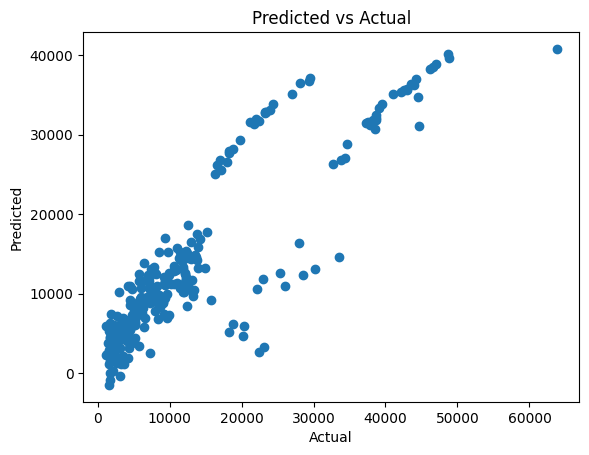

In [11]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

In [12]:
import joblib

joblib.dump(best_model, "insurance_model.pkl")

['insurance_model.pkl']

In [13]:
loaded_model = joblib.load("insurance_model.pkl")

sample = X_test.iloc[:1]
print("Prediction:", loaded_model.predict(sample))

Prediction: [8987.53422054]


## ML Pipeline Report

### 1. Data Loading
- Loaded insurance dataset with mixed features.

---

### 2. Data Cleaning
- No major missing values found.
- Data was directly usable.

---

### 3. Feature Engineering
- Numerical features → StandardScaler
- Categorical features → One-hot encoding

---

### 4. Pipeline
- Combined preprocessing + model into one pipeline
- Ensures reproducibility and avoids data leakage

---

### 5. Model Training
- Used Ridge Regression

---

### 6. Hyperparameter Tuning
- GridSearchCV used to find best alpha value
- Best alpha selected based on cross-validation

---

### 7. Model Evaluation
- Evaluated using MAE, RMSE, R²
- Model shows good predictive performance

---

### 8. Model Saving
- Saved using joblib
- Can be reused without retraining

---

## Conclusion

- Pipeline simplifies ML workflow
- Prevents data leakage
- Ensures consistent preprocessing
- Ready for production use